In [13]:
#Lets do some EDA on the final.csv.
from pathlib import Path
import pandas as pd

data_path = Path("data")
df = pd.read_csv(data_path / "final.csv")
df.head()

,id,url,fullName,parkCode,description,latitude,longitude,latLong,activities,topics,...,activity_camping,activity_scenic_driving,activity_fishing,activity_auto_and_atv,activity_fly_fishing,activity_hunting,activity_arts_and_culture,activity_selfguided_tours__auto,activity_canoeing,activity_park_film
0,6DA17C86-088E-4B4D-B862-7C1BD5CF236B,https://www.nps.gov/acad/index.htm,Acadia National Park,acad,Acadia National Park protects the natural beau...,44.409286,-68.247501,"lat:44.409286, long:-68.247501",[{'id': '09DF0950-D319-4557-A57E-04CD2F63FF42'...,[{'id': '00F3C3F9-2D67-4802-81AE-CCEA5D3BA370'...,...,1,0,1,0,1,0,1,0,1,1
1,6DA17C86-088E-4B4D-B862-7C1BD5CF236B,https://www.nps.gov/acad/index.htm,Acadia National Park,acad,Acadia National Park protects the natural beau...,44.409286,-68.247501,"lat:44.409286, long:-68.247501",[{'id': '09DF0950-D319-4557-A57E-04CD2F63FF42'...,[{'id': '00F3C3F9-2D67-4802-81AE-CCEA5D3BA370'...,...,1,0,1,0,1,0,1,0,1,1
2,6DA17C86-088E-4B4D-B862-7C1BD5CF236B,https://www.nps.gov/acad/index.htm,Acadia National Park,acad,Acadia National Park protects the natural beau...,44.409286,-68.247501,"lat:44.409286, long:-68.247501",[{'id': '09DF0950-D319-4557-A57E-04CD2F63FF42'...,[{'id': '00F3C3F9-2D67-4802-81AE-CCEA5D3BA370'...,...,1,0,1,0,1,0,1,0,1,1
3,6DA17C86-088E-4B4D-B862-7C1BD5CF236B,https://www.nps.gov/acad/index.htm,Acadia National Park,acad,Acadia National Park protects the natural beau...,44.409286,-68.247501,"lat:44.409286, long:-68.247501",[{'id': '09DF0950-D319-4557-A57E-04CD2F63FF42'...,[{'id': '00F3C3F9-2D67-4802-81AE-CCEA5D3BA370'...,...,1,0,1,0,1,0,1,0,1,1
4,6DA17C86-088E-4B4D-B862-7C1BD5CF236B,https://www.nps.gov/acad/index.htm,Acadia National Park,acad,Acadia National Park protects the natural beau...,44.409286,-68.247501,"lat:44.409286, long:-68.247501",[{'id': '09DF0950-D319-4557-A57E-04CD2F63FF42'...,[{'id': '00F3C3F9-2D67-4802-81AE-CCEA5D3BA370'...,...,1,0,1,0,1,0,1,0,1,1


In [14]:
# Find the column index where the first dummy activity variable starts in df
activity_cols = [col for col in df.columns if col.startswith('activity_')]
if activity_cols:
    first_activity_col = activity_cols[0]
    first_activity_index = df.columns.get_loc(first_activity_col)
    print(f"First dummy activity column: {first_activity_col}, index: {first_activity_index}")
else:
    print("No dummy activity columns found.")

First dummy activity column: activity_busshuttle_guided_tour, index: 29


In [15]:
def parks_with_activity(*activities):
    """
    Display parks that have ALL of the specified activities.
    Accepts multiple activities as separate arguments or as a list.
    Example: parks_with_activity('horseback riding', 'hiking')
    """
    # Allow passing a single list as the argument
    if len(activities) == 1 and isinstance(activities[0], (list, tuple)):
        activities = activities[0]
    col_names = [f"activity_{'_'.join(a.lower().split())}" for a in activities]
    missing = [col for col in col_names if col not in df.columns]
    if missing:
        print(f"Missing activity columns: {', '.join(missing)}")
        return
    # Filter parks that have all activities
    mask = df[col_names].eq(1).all(axis=1)
    parks_with_all = df[mask]
    unique_park_names = parks_with_all['fullName'].drop_duplicates()
    print(f"Parks with all activities: {', '.join(activities)}")
    for name in unique_park_names:
        print(name)
    if unique_park_names.empty:
        print("No parks found with all specified activities.")

# Example usage:
parks_with_activity(['skiing', 'hiking'])

Parks with all activities: skiing, hiking
Acadia National Park
Black Canyon Of The Gunnison National Park
Bryce Canyon National Park
Crater Lake National Park
Cuyahoga Valley National Park
Denali National Park & Preserve
Glacier National Park
Grand Teton National Park
Great Basin National Park
Great Sand Dunes National Park & Preserve
Indiana Dunes National Park
Kenai Fjords National Park
Lake Clark National Park & Preserve
Lassen Volcanic National Park
Mesa Verde National Park
Mount Rainier National Park
Olympic National Park
Rocky Mountain National Park
Voyageurs National Park
Yellowstone National Park
Yosemite National Park


C:\Users\Gunnar Griffith\AppData\Local\Temp\ipykernel_32972\2385790127.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top10['fullName'], y=top10['total visits'], palette='viridis')


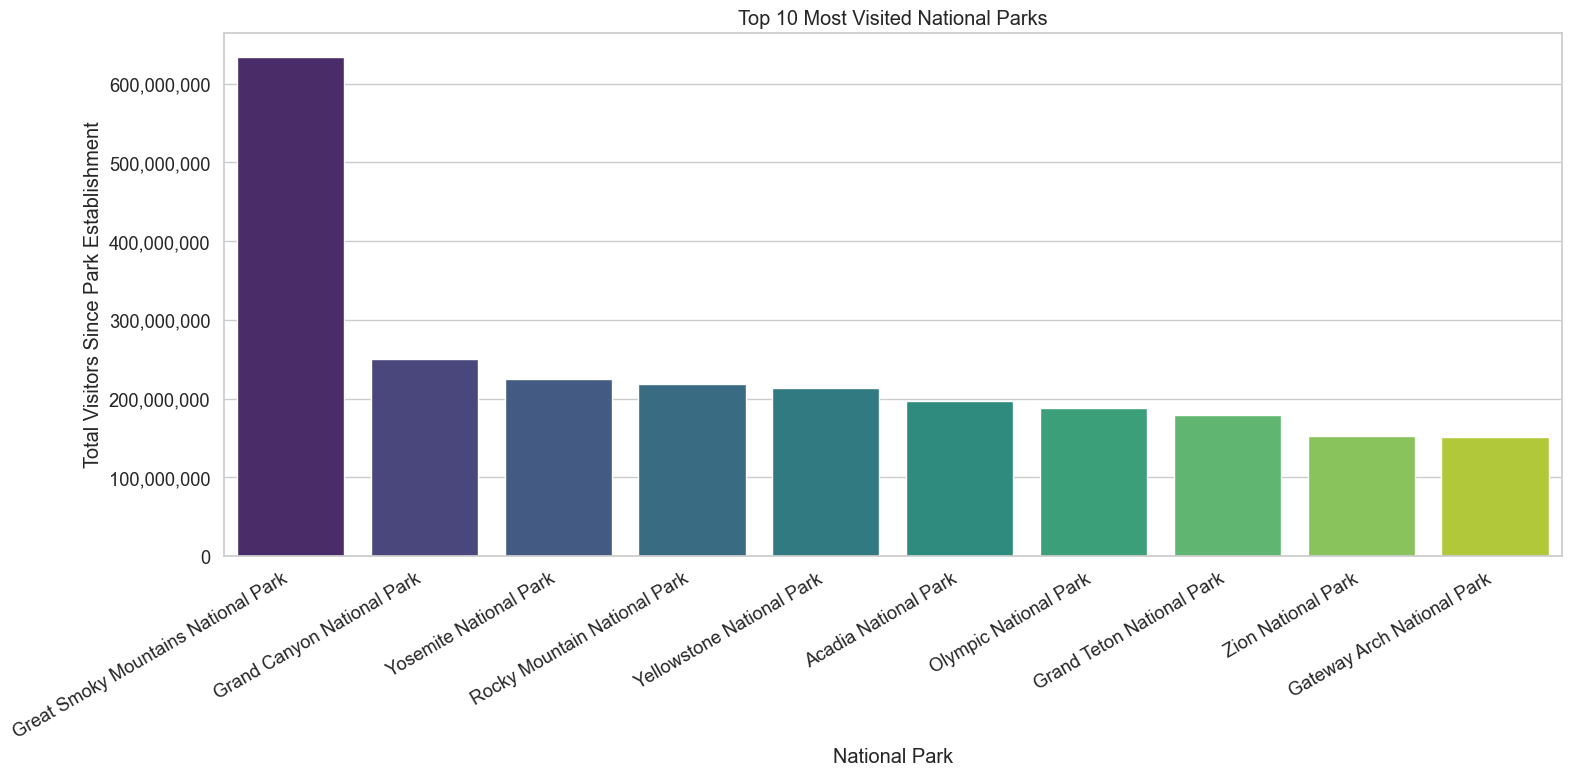

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Set seaborn theme for better visuals
sns.set_theme(style="whitegrid", font_scale=1.2)

# Plot top 10 most visited parks by total visits (one row per park)
if 'fullName' in df.columns and 'total visits' in df.columns:
    unique_parks = df.drop_duplicates(subset='fullName')
    # Remove commas and convert 'total visits' to numeric
    unique_parks['total visits'] = unique_parks['total visits'].astype(str).str.replace(',', '')
    unique_parks['total visits'] = pd.to_numeric(unique_parks['total visits'], errors='coerce')
    top10 = unique_parks.sort_values('total visits', ascending=False).head(10)
    plt.figure(figsize=(16, 8))
    ax = sns.barplot(x=top10['fullName'], y=top10['total visits'], palette='viridis')
    plt.ylabel('Total Visitors Since Park Establishment')
    plt.xlabel('National Park')
    plt.title('Top 10 Most Visited National Parks')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    # Set y-axis to a continuous scale and format ticks
    y_min = 0
    y_max = top10['total visits'].max() * 1.05
    ax.set_ylim(y_min, y_max)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.show()
else:
    print('Required columns (fullName, total visits) not found in DataFrame.')

In [61]:
# Calculate average yearly growth for each park
# Assumes columns: 'fullName', 'year', 'annual visits' (with commas removed)

growth_dict = {}
if all(col in df.columns for col in ['fullName', 'year', 'annual visits']):
    # Clean up 'annual visits' column
    df['annual visits'] = df['annual visits'].astype(str).str.replace(',', '')
    df['annual visits'] = pd.to_numeric(df['annual visits'], errors='coerce')
    df['year'] = pd.to_numeric(df['year'], errors='coerce')
    for park, group in df.groupby('fullName'):
        group_sorted = group.sort_values('year')
        visits = group_sorted['annual visits'].values
        if len(visits) > 1:
            growth = visits[1:] - visits[:-1]
            avg_growth = growth.mean()
            growth_dict[park] = avg_growth
    print("Average yearly growth for each park (top 10 by growth):")
    for park, growth in sorted(growth_dict.items(), key=lambda x: x[1], reverse=True)[:10]:
        print(f"{park}: {growth:,.0f}")
else:
    print("Required columns ('fullName', 'year', 'annual visits') not found in DataFrame.")

Average yearly growth for each park (top 10 by growth):
Great Smoky Mountains National Park: 120,999
Cuyahoga Valley National Park: 53,807
Indiana Dunes National Park: 49,600
Zion National Park: 47,007
New River Gorge National Park & Preserve: 42,125
Grand Canyon National Park: 41,443
Olympic National Park: 39,800
Yellowstone National Park: 39,250
Grand Teton National Park: 39,054
Acadia National Park: 37,880


C:\Users\alden\AppData\Local\Temp\ipykernel_15580\765278100.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=growth_series.index, y=growth_series.values, palette='mako')


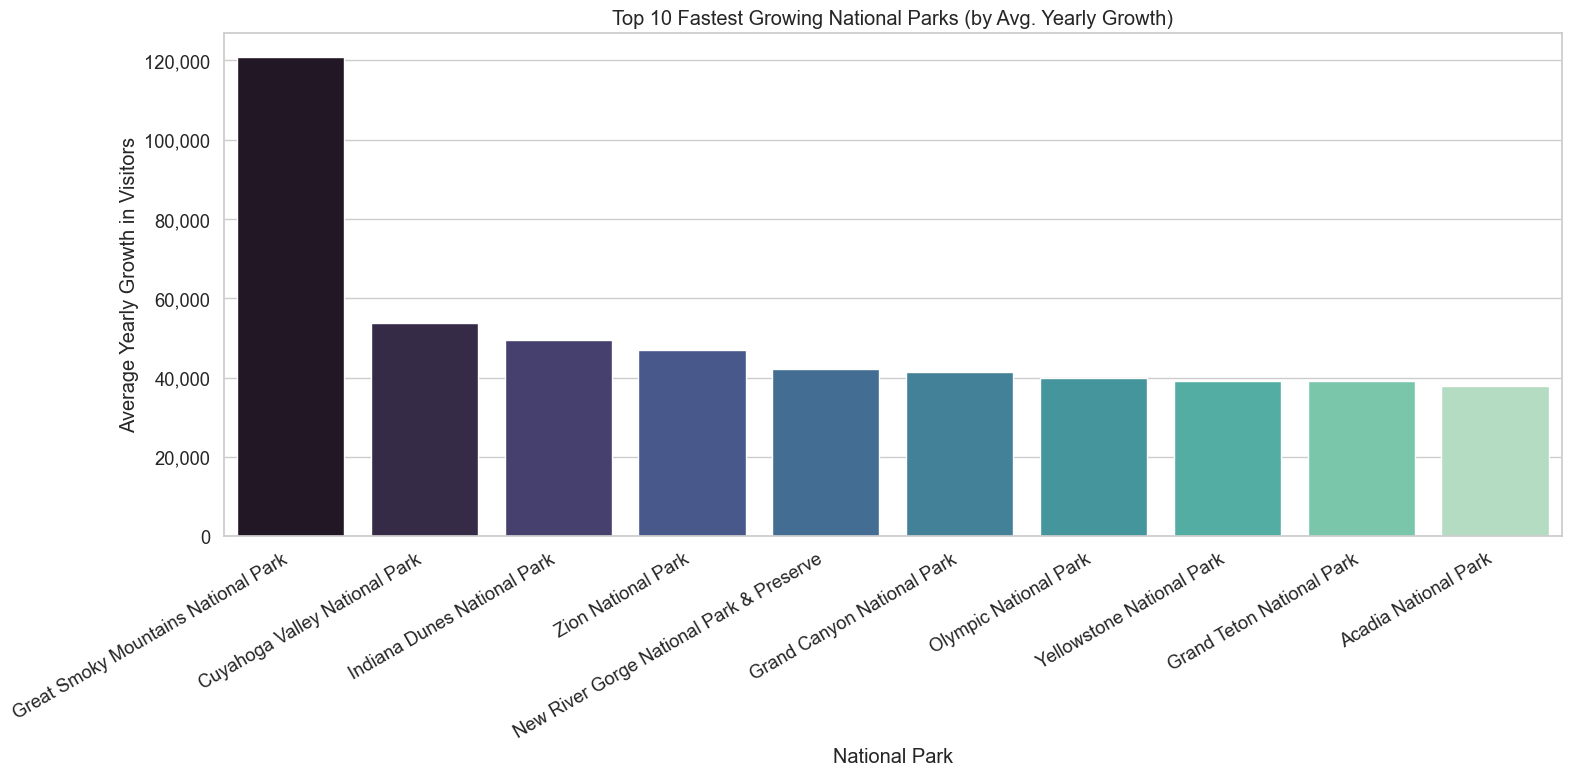

In [62]:
# Bar plot of top 10 fastest growing parks by average yearly growth
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Prepare data for plotting
if growth_dict:
    growth_series = pd.Series(growth_dict).sort_values(ascending=False).head(10)
    plt.figure(figsize=(16, 8))
    ax = sns.barplot(x=growth_series.index, y=growth_series.values, palette='mako')
    plt.ylabel('Average Yearly Growth in Visitors')
    plt.xlabel('National Park')
    plt.title('Top 10 Fastest Growing National Parks (by Avg. Yearly Growth)')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.show()
else:
    print('No growth data available to plot.')

In [66]:
# Find activities present in all top 10 most visited parks
activity_cols = [col for col in df.columns if col.startswith('activity_')]

# Remove commas and convert 'total visits' to numeric for sorting
parks_visits = df.drop_duplicates(subset='fullName').copy()
parks_visits['total visits'] = parks_visits['total visits'].astype(str).str.replace(',', '')
parks_visits['total visits'] = pd.to_numeric(parks_visits['total visits'], errors='coerce')
top10_parks = parks_visits.sort_values('total visits', ascending=False).head(10)['fullName']
top10_df = df[df['fullName'].isin(top10_parks)]

activities_in_all_top10 = []
for col in activity_cols:
    # Check if all top 10 parks have this activity (at least one row per park with value 1)
    parks_with_activity = top10_df[top10_df[col] == 1]['fullName'].unique()
    if set(parks_with_activity) == set(top10_parks):
        activities_in_all_top10.append(col)


# Optionally, strip 'activity_' prefix for readability
if activities_in_all_top10:
    print("\nCleaned activity names:")
    for act in activities_in_all_top10:
        print(act.replace('activity_', '').replace('_', ' ').title())
else:
    print("None found.")


Cleaned activity names:
Shopping
Bookstore And Park Store
Junior Ranger Program
